<a href="https://colab.research.google.com/github/Amrhesham1/Solution1/blob/master/Classification_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification - Mini-Project 2

***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: Maya Haytham

ID: 58-2042

Tutorial: T09

---

Name: Youssef Hatem

ID: 58-21368

Tutorial: T09

---


## Dataset Description

The following dataset includes information about loan applicants, including factors such as income, credit score, employment status, loan details, and other indicators of financial stability, along with the final decision showing whether each loan was approved or not.

| Column | Description|
|-|-|
|ApplicationNumber|Unique identifier assigned to each loan application|
|Age|Applicant’s age in years|
|AnnualIncome|Applicant’s yearly income|
|CreditScore|A score representing the applicant’s creditworthiness|
|EmploymentStatus|Applicant’s current employment situation (Employed, Unemployed, Self-Employed)|
|EducationLevel|Highest educational qualification attained (Highschool, Bachelor, Master, Doctorate, Diploma)|
|LoanAmount|Total amount of money requested for the loan|
|LoanDuration|Duration of the loan in months|
|MaritalStatus|Applicant’s marital state (Divorced, Married, Single, Widowed)|
|NumberOfDependents|Number of individuals financially dependent on the applicant|
|HomeOwnershipStatus|Applicant’s housing status (Mortagage, Own, Rent, Other)|
|BankruptcyHistory|Indicates whether the applicant has previously declared bankruptcy (0 = No, 1 = Yes)|
|LoanPurpose|The primary reason for taking the loan (Debt Consolidation, Home Improvement, Education, Personal)|
|PreviousLoanDefaults|Indicates if the applicant has defaulted on any previous loans (0 = No, 1 = Yes)|
|MonthlyLoanPayment|Amount the applicant would need to pay monthly to repay the loan|
|MonthlyIncome|Average monthly income of the applicant|
|JobTenure|Number of years the applicant has been in their current job|
|LoanApproved|Indicates loan approval status (No = Not Approved, Yes = Approved)|

## Importing Libraries & Dataset

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#plt.style.use("seaborn")

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')
df.head()

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
3,20628,18,"$92,094.00",565,Employed,Bachelor,"$72,738.00",36 months,Single,1,Mortgage,0,Vehicle,0,NaN,"$7,674.50",3,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No


## Data Inspection

In [135]:
df.shape


(20000, 18)

We did this method to see how many rows and how many coulmns are avaialble in the data set.

In [136]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ApplicationNumber     20000 non-null  int64 
 1   Age                   20000 non-null  int64 
 2   AnnualIncome          20000 non-null  object
 3   CreditScore           20000 non-null  int64 
 4   EmploymentStatus      16260 non-null  object
 5   EducationLevel        20000 non-null  object
 6   LoanAmount            20000 non-null  object
 7   LoanDuration          20000 non-null  object
 8   MaritalStatus         20000 non-null  object
 9   NumberOfDependents    20000 non-null  int64 
 10  HomeOwnershipStatus   20000 non-null  object
 11  BankruptcyHistory     20000 non-null  int64 
 12  LoanPurpose           20000 non-null  object
 13  PreviousLoanDefaults  20000 non-null  int64 
 14  MonthlyLoanPayment    15660 non-null  object
 15  MonthlyIncome         17160 non-null

Checking the data types and and null values, knwoing from it that EmploymentStatus, MonthlyLoanPayment, and MonthlyIncome have missing values that will need to be handled .

In [137]:
df.describe()

,ApplicationNumber,Age,CreditScore,NumberOfDependents,BankruptcyHistory,PreviousLoanDefaults,JobTenure
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.0,20000.000000,20000.000000
mean,20500.500000,39.752600,571.612400,1.517300,0.0,0.100050,5.002650
std,5773.647028,11.622713,50.997358,1.386325,0.0,0.300074,2.236804
min,10501.000000,18.000000,343.000000,0.000000,0.0,0.000000,0.000000
25%,15500.750000,32.000000,540.000000,0.000000,0.0,0.000000,3.000000
50%,20500.500000,40.000000,578.000000,1.000000,0.0,0.000000,5.000000
75%,25500.250000,48.000000,609.000000,2.000000,0.0,0.000000,6.000000
max,30500.000000,80.000000,712.000000,5.000000,0.0,1.000000,16.000000


df.describe() is important because it gives a quick summary of all numerical columns. It helps me see the basic statistics like the mean, minimum, maximum, and quartiles. This makes it easier to spot unusual values, understand the range of the data, and know what needs cleaning before modeling.

In [138]:
df.isnull().sum()

,0
ApplicationNumber,0
Age,0
AnnualIncome,0
CreditScore,0
EmploymentStatus,3740
EducationLevel,0
LoanAmount,0
LoanDuration,0
MaritalStatus,0
NumberOfDependents,0


Making sure for the missing values as well.

In [139]:
df.duplicated().sum()

np.int64(0)

Checking for duplicate rows in the data set and knowing by the results that there are none.

In [140]:
df.head()

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
3,20628,18,"$92,094.00",565,Employed,Bachelor,"$72,738.00",36 months,Single,1,Mortgage,0,Vehicle,0,NaN,"$7,674.50",3,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No


Checking the first 5 coulmns in tha data set.


## Data Cleaning

In [141]:
cols_to_clean = [
    "AnnualIncome",
    "LoanAmount",
    "LoanDuration",
    "MonthlyLoanPayment",
    "MonthlyIncome"
]
for col in cols_to_clean:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.replace(",", "", regex=False)
    df[col] = df[col].str.replace("$", "", regex=False)
    df[col] = df[col].str.replace("LE", "", regex=False)
    if col == "LoanDuration":
        df[col] = df[col].str.replace(" months", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ApplicationNumber     20000 non-null  int64  
 1   Age                   20000 non-null  int64  
 2   AnnualIncome          20000 non-null  float64
 3   CreditScore           20000 non-null  int64  
 4   EmploymentStatus      16260 non-null  object 
 5   EducationLevel        20000 non-null  object 
 6   LoanAmount            20000 non-null  float64
 7   LoanDuration          20000 non-null  int64  
 8   MaritalStatus         20000 non-null  object 
 9   NumberOfDependents    20000 non-null  int64  
 10  HomeOwnershipStatus   20000 non-null  object 
 11  BankruptcyHistory     20000 non-null  int64  
 12  LoanPurpose           20000 non-null  object 
 13  PreviousLoanDefaults  20000 non-null  int64  
 14  MonthlyLoanPayment    15660 non-null  float64
 15  MonthlyIncome      

We removed the $ sign, the commas, the spaces, the word months, and anything that can be an obstacle to convert to float datatype from all these object data type coloumns so we can convert them to numeric and then after cleaning them we changed these data types into numeric

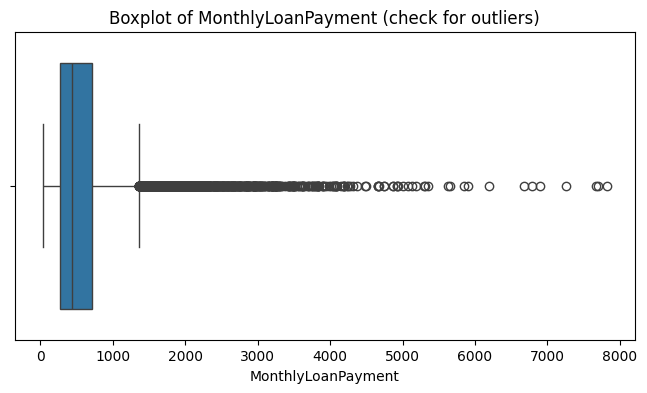

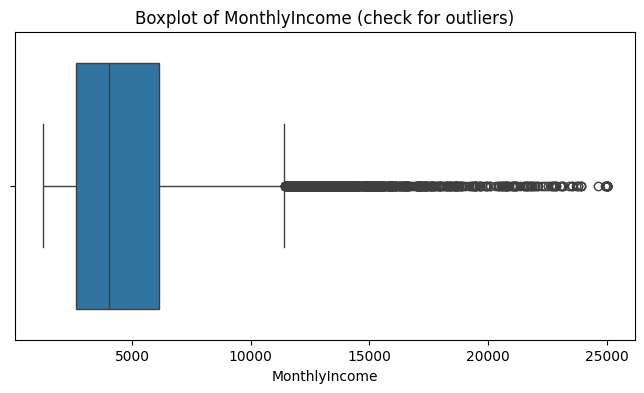

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
cols_to_check = ['MonthlyLoanPayment', 'MonthlyIncome']
for col in cols_to_check:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col} (check for outliers)")
    plt.show()


We double checked for outliers and one of the reasons we didnt use the mean is due to outliers because it would result in in accurate data

In [143]:
num_cols = [
    "AnnualIncome", "LoanAmount", "LoanDuration",
    "MonthlyLoanPayment", "MonthlyIncome"
]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
df["EmploymentStatus"] = df["EmploymentStatus"].fillna(df["EmploymentStatus"].mode()[0])


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ApplicationNumber     20000 non-null  int64  
 1   Age                   20000 non-null  int64  
 2   AnnualIncome          20000 non-null  float64
 3   CreditScore           20000 non-null  int64  
 4   EmploymentStatus      20000 non-null  object 
 5   EducationLevel        20000 non-null  object 
 6   LoanAmount            20000 non-null  float64
 7   LoanDuration          20000 non-null  int64  
 8   MaritalStatus         20000 non-null  object 
 9   NumberOfDependents    20000 non-null  int64  
 10  HomeOwnershipStatus   20000 non-null  object 
 11  BankruptcyHistory     20000 non-null  int64  
 12  LoanPurpose           20000 non-null  object 
 13  PreviousLoanDefaults  20000 non-null  int64  
 14  MonthlyLoanPayment    20000 non-null  float64
 15  MonthlyIncome      

Now, the first step as mentioned previously that we did was check for outliers , and there were outliers and therefor the median was used. not only because of the outliers but we used the median for numerical coulmns , and on the other hand we used mode for the categorical coulmns. And finally we checked by the info() method that all missing values were handled.

In [145]:
cat_cols = ["EmploymentStatus", "EducationLevel", "MaritalStatus",
            "HomeOwnershipStatus", "LoanPurpose", "LoanApproved"]
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.capitalize()
df.head()

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36,Single,3,Mortgage,0,Debt consolidation,0,623.110,2249.33,3,No
1,13176,18,22825.0,581,Self-employed,Master,30457.0,24,Single,0,Rent,0,Home improvement,0,1269.040,1902.08,5,No
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,No
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,No
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36,Married,3,Rent,0,Home improvement,0,778.360,2973.83,1,No


Making sure the first letter is capitalized for all categorical coulmns.

In [146]:
df['Monthly_Debt_To_Income_Ratio'] = df['MonthlyLoanPayment'] / df['MonthlyIncome']

Applying the feature engineer "Monthly_Debt_To_Income_Ratio" column, which indicates the applicant’s ratio of debt
to income per month.


In [147]:
df[['MonthlyLoanPayment', 'MonthlyIncome', 'Monthly_Debt_To_Income_Ratio']].head()


,MonthlyLoanPayment,MonthlyIncome,Monthly_Debt_To_Income_Ratio
0,623.110,2249.33,0.277020
1,1269.040,1902.08,0.667185
2,318.570,6324.25,0.050373
3,439.185,7674.50,0.057227
4,778.360,2973.83,0.261737


The ratio of the monthly loan payment of the applicant (MonthlyLoanPayment) to the monthly income of the applicant (MonthlyIncome) is considered this feature. It shows the amount of the monthly income of the applicant that is currently obligated by the loan repayment. Applicants who have a high debt to income ratio are also likely to find it hard to make extra payments on the loans and this may influence the loan approval.

In [148]:
df.head()

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved,Monthly_Debt_To_Income_Ratio
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36,Single,3,Mortgage,0,Debt consolidation,0,623.110,2249.33,3,No,0.277020
1,13176,18,22825.0,581,Self-employed,Master,30457.0,24,Single,0,Rent,0,Home improvement,0,1269.040,1902.08,5,No,0.667185
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,No,0.050373
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,No,0.057227
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36,Married,3,Rent,0,Home improvement,0,778.360,2973.83,1,No,0.261737


## Exploratory Data Analysis

**Q1: On average, which type of educational level has the highest approval rate? Show their order on the graph.**

In [149]:
df['LoanApproved'] = df['LoanApproved'].str.strip().str.capitalize()

approval_rate = df.groupby('EducationLevel')['LoanApproved'].apply(lambda x: (x=="Yes").mean()).reset_index()
approval_rate = approval_rate.sort_values(by='LoanApproved', ascending=False)

print(approval_rate)

  EducationLevel  LoanApproved
2      Doctorate      0.440252
4         Master      0.350820
0       Bachelor      0.266435
1        Diploma      0.204264
3    High school      0.144381


**Visualization**

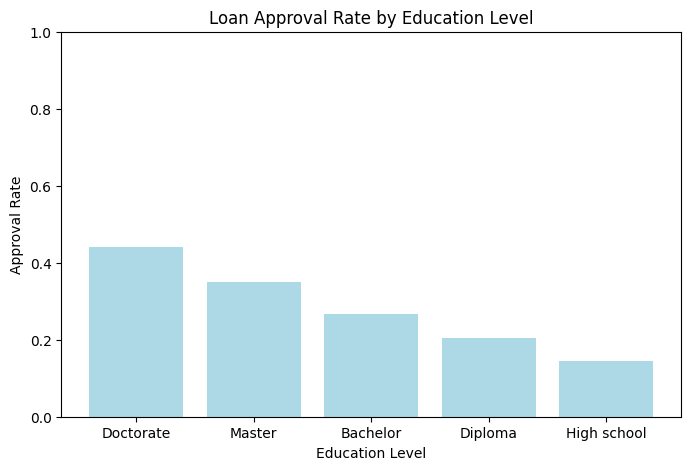

In [150]:
plt.figure(figsize=(8,5))
plt.bar(approval_rate['EducationLevel'], approval_rate['LoanApproved'], color='lightblue')
plt.ylabel('Approval Rate')
plt.xlabel('Education Level')
plt.title('Loan Approval Rate by Education Level')
plt.ylim(0, 1)
plt.show()

**Answer for Q1**: The table indicates the average loan approval rate on each of the levels. The highest approval rate of 44 is recorded by applicants having a Doctorate and 35 by those with Masters degree, 27 with Bachelors, 20 with Diploma and 14 with High school graduates. This suggests that, on the average, the more the level of education, the more probable that a loan is approved in this data.

**Q2: How does the annual income vary among approved applicants? Interpret the values of the 3 quartiles.**

In [151]:
approved_df = df[df['LoanApproved'] == "Yes"]


Selecting only approved applicants

In [152]:
Q1 = approved_df['AnnualIncome'].quantile(0.25)
Q2 = approved_df['AnnualIncome'].quantile(0.50)
Q3 = approved_df['AnnualIncome'].quantile(0.75)


we calculated the three quartiles of annual income, the first one is Q1 which is the 25th percentile , Q2 the median, and Q3 the 75th percentile. These values show how the income data is spread out and are used to create the box plot.

**Visualization**

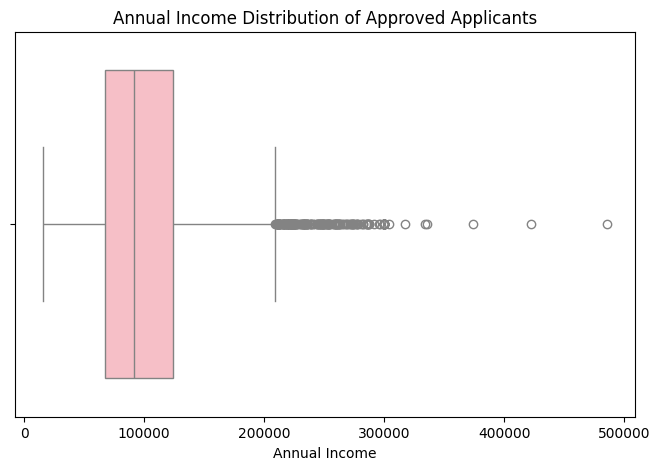

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=approved_df['AnnualIncome'], color='lightpink')
plt.title('Annual Income Distribution of Approved Applicants')
plt.xlabel('Annual Income')
plt.show()


**Answer for Q2**: The annual income distribution of the approved applicants is skewed positively and the majority of the incomes are between 50k and 120k and the median is about 90k. High-income outliers comprise a large range between 150k and 500k suggesting that a few approved applicants have very high incomes, but most of the applicants are not at the upper end and are located within a much stricter range.

**Q3: How does the age of an applicant affect their credit score? (Hint: Use the line of best fit.)**

**Visualization**

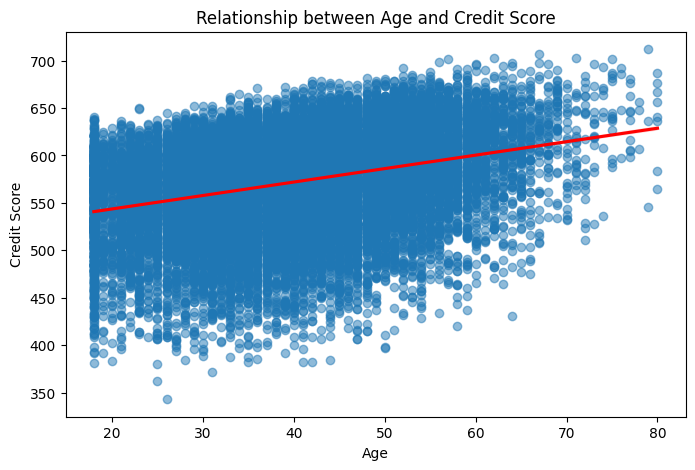

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.regplot(x='Age', y='CreditScore', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between Age and Credit Score')
plt.xlabel('Age')
plt.ylabel('Credit Score')
plt.show()


**Answer for Q3**: according to the best fit line (regression line) as age increase the credit score increases as well. Moreover, in my opion according to the dots , since they are closley related to the line it shows that age is a strong predictor for credit score. Howver some outliers exist.

**Q4: Is the distribution of applicants' income per month normal or skewed?**

**Visualization**

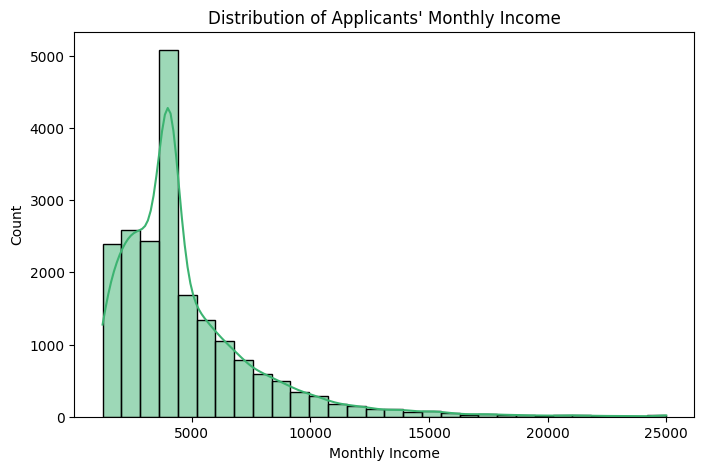

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True, color='mediumseagreen')
plt.title('Distribution of Applicants\' Monthly Income')
plt.xlabel('Monthly Income')
plt.show()


**Answer for Q4**: The monthly incomes of applicants are skewed, that is, it is right-skewed (positively skewed).The graph indicates that the majority of the people in the dataset earn either low or average monthly income and few of them earn a lot which leads us to the occurrence of outliers; that makes the left side of the graph high and the right side gradually decreases. That is, there are large numbers of applicants with low incomes, and few with very high incomes (Often, there are huge numbers of people with incomes below the mean level, and very few with very high incomes).

## Data Preparation for Modelling

In [156]:
df_encoded = df.copy()

We make a copy of the original cleaned dataset so we can encode and transform data without changing the main dataframe.

In [157]:
categorical_features = df_encoded.select_dtypes(include=['object']).columns.tolist()
categorical_features


['EmploymentStatus',
 'EducationLevel',
 'MaritalStatus',
 'HomeOwnershipStatus',
 'LoanPurpose',
 'LoanApproved']

We extract all object-type columns because these are the categorical features that need encoding

In [158]:
df_encoded['EducationLevel'] = df_encoded['EducationLevel'].astype('category').cat.codes
df_encoded['EducationLevel']


,EducationLevel
0,1
1,4
2,0
3,0
4,1
...,...
19995,1
19996,2
19997,0
19998,1


We choose EducationLevel because it usually has ordered levels. Therefor we convert it into “category” data type and use .cat.codes to assign each level a numeric code. This preserves its order

In [159]:
categorical_features.remove('EducationLevel')
categorical_features


['EmploymentStatus',
 'MaritalStatus',
 'HomeOwnershipStatus',
 'LoanPurpose',
 'LoanApproved']

Since now EducationLevel was encoded numerically, we removed it from the list so its not one-hot encoded again.

In [160]:
df_encoded = pd.get_dummies(df_encoded, columns=categorical_features)
df_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ApplicationNumber               20000 non-null  int64  
 1   Age                             20000 non-null  int64  
 2   AnnualIncome                    20000 non-null  float64
 3   CreditScore                     20000 non-null  int64  
 4   EducationLevel                  20000 non-null  int8   
 5   LoanAmount                      20000 non-null  float64
 6   LoanDuration                    20000 non-null  int64  
 7   NumberOfDependents              20000 non-null  int64  
 8   BankruptcyHistory               20000 non-null  int64  
 9   PreviousLoanDefaults            20000 non-null  int64  
 10  MonthlyLoanPayment              20000 non-null  float64
 11  MonthlyIncome                   20000 non-null  float64
 12  JobTenure                       

We applied one hot encoding to the remaining categorical columns, there for as shown above they are now changed in a form on boolean.

In [161]:
y = df_encoded['LoanApproved_Yes']

X = df_encoded.drop(['LoanApproved_Yes', 'LoanApproved_No', 'ApplicationNumber'], axis='columns')



In this stage, we pre-processed the dataset to do the modeling by isolating the target variable and the features. The desired y is established to be LoanApproved_Yes which is the thing we want the model to predict. The X are all the other columns that the model can predict with, therefore we dropped LoanApproved_Yes which is the target itself, LoanApproved_No in order to avoid target leakage because it directly implies the inverse of the target and ApplicationNumber which is an ID. This will make the model learn only the relevant information in making predictions such as loan approvals.

In [162]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)


LoanApproved_Yes
False    15220
True      4780
Name: count, dtype: int64
LoanApproved_Yes
False    76.1
True     23.9
Name: proportion, dtype: float64


Checking whether the dataset is imbalanced or not, in this case itrs definitely imbalanced since the rejection rate is 76% and the acceptance is around 24%, therefor there is a huge diffrence between them , and because of that it is more useful to look at sensitivity and precision and not to accuracy or error rate.


In [163]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


As all our labs , we need to split the data into a training dataset and a testing dataset to assess the model's generalizability on unseen data as we mentioned in lab 6.

## Modelling

In [164]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)



## Evaluation

In [165]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def print_score(clf, X_train, y_train, X_test, y_test, train=True):
    if train:
        pred = clf.predict(X_train)
        clf_report = pd.DataFrame(classification_report(y_train, pred, output_dict=True))
        print("Train Result:")
        print("===============================================")
        print(f"Accuracy Score: {accuracy_score(y_train, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, pred)}\n")

    elif train==False:
        pred = clf.predict(X_test)
        clf_report = pd.DataFrame(classification_report(y_test, pred, output_dict=True))
        print("Test Result:")
        print("===============================================")
        print(f"Accuracy Score: {accuracy_score(y_test, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_test, pred)}\n")

The following is simply a helper method that we will make use of later on that will print out some of the performance measures of the model in a wellformatted block of text.

In [166]:
print_score(tree_clf, X_train, y_train, X_test, y_test, train=True)
print_score(tree_clf, X_train, y_train, X_test, y_test, train=False)

Train Result:
Accuracy Score: 100.00%
_______________________________________________
CLASSIFICATION REPORT:
             False    True  accuracy  macro avg  weighted avg
precision      1.0     1.0       1.0        1.0           1.0
recall         1.0     1.0       1.0        1.0           1.0
f1-score       1.0     1.0       1.0        1.0           1.0
support    10657.0  3343.0       1.0    14000.0       14000.0
_______________________________________________
Confusion Matrix: 
 [[10657     0]
 [    0  3343]]

Test Result:
Accuracy Score: 82.95%
_______________________________________________
CLASSIFICATION REPORT:
                 False         True  accuracy    macro avg  weighted avg
precision     0.893333     0.638000    0.8295     0.765667      0.832181
recall        0.880999     0.665971    0.8295     0.773485      0.829500
f1-score      0.887123     0.651685    0.8295     0.769404      0.830736
support    4563.000000  1437.000000    0.8295  6000.000000   6000.000000
_________

The training data is only evaluated to demonstrate. In the default values used by the sklearn decision trees, the tree overfits the training data. Record the 100 percent accuracy rate when assessing the training set, but 80 percent accuracy rate when assessing the test set.

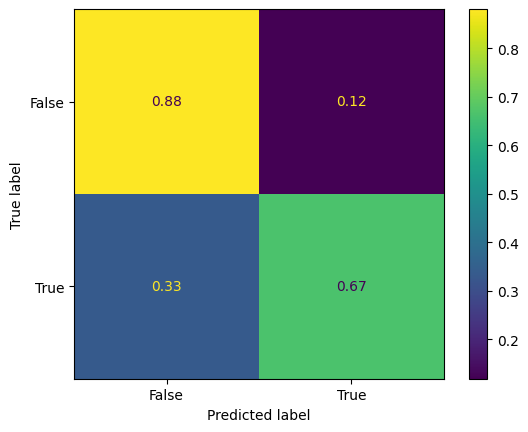

In [167]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, tree_clf.predict(X_test), labels=tree_clf.classes_,normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=tree_clf.classes_)
disp.plot()
plt.grid(False)

In [168]:
from sklearn.metrics import f1_score, precision_score, recall_score

pred = tree_clf.predict(X_test)

print('Precision: ',precision_score(y_test,pred))
print('Recall: ',recall_score(y_test,pred))
print('F1_score: ',f1_score(y_test,pred))

Precision:  0.638
Recall:  0.6659707724425887
F1_score:  0.651685393258427


The outcome of these results informs us of the predictive ability of the model in loan approvals. Precision (0.638) denotes that with the model predicting that a loan is being approved, it is right in 64% of the times. Recall (0.666) is the average of all the loans which were actually approved; the model identifies approximately 67 of those loans. The balance is indicated by the F1-score (0.652), which indicates the overall performance of the model, indicating the model is capable of making correct predictions of approvals at the expense of errors. Concisely, the model is a good model but it still lacks some approved loans and it also makes incorrect predictions in loans that are to be approved.


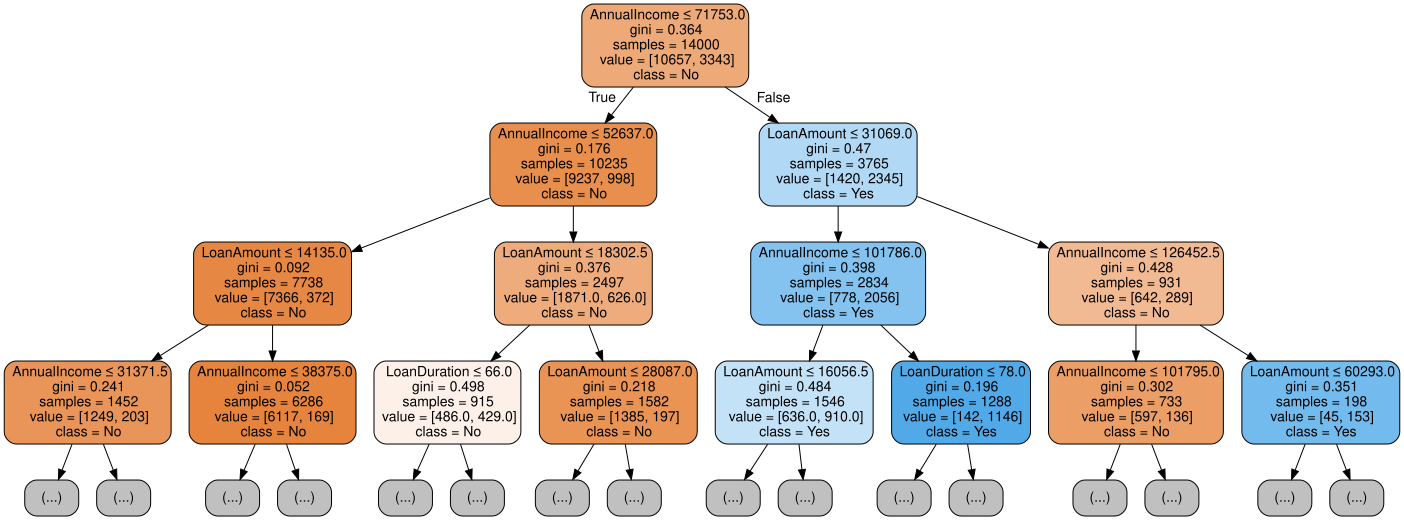

In [172]:
import graphviz
from sklearn.tree import export_graphviz

dot_data = export_graphviz(
    tree_clf,
    out_file=None,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3
)

graph = graphviz.Source(dot_data)
graph


This is a visualization of the tree, we made that the depth is 3 so that its more readable.

According to the decision tree, annual income of the applicant is the most significant issue in granting a loan. Those whose income is low are often disapproved, particularly when they request a huge loan. Increase in income will increase the possibility of approval and this will be so in cases where the loan value is low and the period of repayment takes not too long. Overall, the model grants loans to applicants who make a sufficient income and demand affordable amounts of loans, and it denies loans when income is low or the demanded loan is too large in relation to income of the applicant.

## Bonus (Optional)

**Apply a different classification algorithm, compare the models’ performance using an appropriate metric, which of
the two models that you applied will you choose? and why?**

In [171]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

rf_clf = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("Random Forest Performance")
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))


Random Forest Performance
Precision: 0.8186356073211315
Recall: 0.6847599164926931
F1-score: 0.7457370215990906


Comparing the decision tree and the random forest models, it is evident that the random forest is better. It is more precise (0.82 vs 0.64) in its predictions of approved loans are more precise, and slightly higher recall (0.69 vs 0.67), that is, it identifies more of the real approved loans. It also has a better F1-score (0.75 vs 0.65) indicating a greater balance between precision and recall. Generally, the Random Forest is superior and more precise in comparison with the Decision Tree, and hence it is preferred when it comes to the prediction of loan approvals.

According to our research on this clasification algorithm, its normal that the random forest preforms better than the descision tree; The decision tree is a single model where it may overfit the training data and therefor errors occur and therefor decreasing precision. However, Random forest is a collection of numerous trees. It computes the average of their predictions making it less prone to overfitting and errors. which makes the resulsts reasonable.